# ARTI 308 – Lab 5: Feature Engineering (Classification)
## Order Status Prediction using a Talabat-style Orders Dataset

### Lab focus
This dataset is already clean (no missing values, no duplicate rows, consistent data types).  
In this lab, we focus on **feature engineering** for a classification task, not on data cleaning.

### Objective
Build a baseline model to predict `Order_Status` (Delivered, Cancelled, In Transit) and learn how feature engineering choices affect model performance and feature importance.

In this lab we will:
1) Load and inspect the dataset  
2) Define the target and select usable predictors (avoid leakage features)  
3) Engineer new features (time-based, price-based, distance-based)  
4) Encode categorical features  
5) Train a baseline **Random Forest** classifier  
6) Interpret performance and feature importance  

## 1. Setup and imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. Load the dataset

In [2]:
DATA_PATH = "talabat_enhanced_orders.csv"  # ensure the file is in the same folder as this notebook
df = pd.read_csv(DATA_PATH)

df.head(10)


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,Alexandria,Wallet,Delivered,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,Zagazig,Credit Card,Delivered,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,Assiut,Cash,In Transit,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,Mansoura,Cash,Delivered,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,Mansoura,Wallet,Delivered,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online
5,6,U7439,750,270,Sushi,3,205.44,2025-06-04 12:16:00,2025-06-04 12:45:00,29,Mansoura,Credit Card,Delivered,Bicycle,31.024140,31.387817,31.029004,31.373869,31.022573,31.380646,1.436807,Medium,Online
6,7,U8948,827,4,Sushi,1,133.94,2025-06-11 04:09:00,2025-06-11 04:49:00,40,Cairo,Wallet,Delivered,Bicycle,30.026723,31.249101,30.043525,31.233372,30.038769,31.231835,2.402167,Low,Online
7,8,U8672,908,109,Shawarma,5,404.80,2025-06-12 18:37:00,2025-06-12 19:18:00,41,Mansoura,Cash,Delivered,Bicycle,31.052547,31.392976,31.053352,31.362834,31.049187,31.373710,2.878434,High,Online
8,9,U2205,814,215,Pizza,1,101.03,2025-06-01 22:18:00,2025-06-01 23:05:00,47,Mansoura,Credit Card,Delivered,Motorbike,31.041945,31.375128,31.041036,31.385503,31.041062,31.368488,0.995562,Low,Online
9,10,U7411,362,416,Pizza,1,130.05,2025-06-09 00:18:00,2025-06-09 01:04:00,46,Cairo,Wallet,Delivered,Bicycle,30.052723,31.236077,30.025107,31.229281,30.062032,31.227642,3.130713,Low,Online


The first rows confirm that the dataset loaded correctly.  
Each row represents one food delivery order, including information about the customer, restaurant, driver, and order outcome (`Order_Status`).

## 3. Quick dataset checks (cleanliness confirmation)

In [3]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (100000, 23)

Missing values per column:


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


We confirm the dataset is clean: no missing values and no duplicated rows.  
Therefore, we will spend our effort on feature engineering rather than cleaning.

## 4. Target variable and class balance

In [4]:
target_col = "Order_Status"
df[target_col].value_counts()

Order_Status
Delivered     85197
Cancelled      9812
In Transit     4991
Name: count, dtype: int64

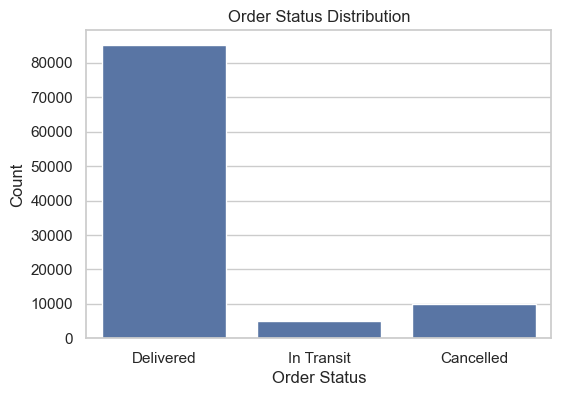

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

This bar chart shows whether the classes are balanced.  
If one class dominates, the model may learn to predict that class more often, so we must interpret accuracy carefully and also look at the confusion matrix.

## 5. Identify feature types

In [6]:
df.dtypes

Order_ID                       int64
User_ID                          str
Restaurant_ID                  int64
Driver_ID                      int64
Item_Name                        str
Quantity                       int64
Total_Price                  float64
Order_Time                       str
Delivery_Time                    str
Delivery_Duration_Minutes      int64
City                             str
Payment_Method                   str
Order_Status                     str
Driver_Vehicle                   str
Restaurant_Lat               float64
Restaurant_Lon               float64
Customer_Lat                 float64
Customer_Lon                 float64
Driver_Lat                   float64
Driver_Lon                   float64
Delivery_Distance_km         float64
Traffic_Level                    str
Driver_Availability              str
dtype: object

We have a mixture of numerical features (e.g., `Quantity`, `Total_Price`, distances) and categorical features (e.g., `City`, `Payment_Method`, `Traffic_Level`).  
This is a common real-world situation where feature engineering and encoding become essential.


## 6. Leakage awareness (important)

When designing a prediction task, we must avoid using features that would not be available at prediction time.

For example, if we want to predict the order status **right after the customer places the order**, we should not use:
- `Delivery_Time` (known only later)
- `Delivery_Duration_Minutes` (known only after delivery)

In this lab, we will **exclude** obvious leakage features and focus on information that is typically available early in the order lifecycle.


## 7. Feature engineering

### 7.1 Time-based features from `Order_Time`
We convert `Order_Time` into a datetime, then extract:
- hour of day  
- day of week  
- weekend flag  
- peak hour flag (example rule: lunch and dinner periods)


In [7]:
df_fe = df.copy()

# Parse time columns
df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"], errors="coerce")

df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek  # Monday=0, Sunday=6
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([5,6]).astype(int)

# Simple peak-hour rule (you can adjust based on local context):
# Lunch: 12-15, Dinner: 19-23
df_fe["is_peak_hour"] = df_fe["order_hour"].isin(list(range(12,16)) + list(range(19,24))).astype(int)

df_fe[["Order_Time","order_hour","order_dayofweek","is_weekend","is_peak_hour"]].head(10)


,Order_Time,order_hour,order_dayofweek,is_weekend,is_peak_hour
0,2025-06-16 08:32:00,8,0,0,0
1,2025-06-03 21:27:00,21,1,0,1
2,2025-06-01 14:48:00,14,6,1,1
3,2025-06-13 02:30:00,2,4,0,0
4,2025-06-06 09:48:00,9,4,0,0
5,2025-06-04 12:16:00,12,2,0,1
6,2025-06-11 04:09:00,4,2,0,0
7,2025-06-12 18:37:00,18,3,0,0
8,2025-06-01 22:18:00,22,6,1,1
9,2025-06-09 00:18:00,0,0,0,0


We transformed the original timestamp into multiple meaningful features.  
Models often learn better from these engineered features than from raw timestamps.


### 7.2 Price-based features
We create a feature that captures the price per item:
`price_per_item = Total_Price / Quantity`

This can help the model differentiate between an expensive order with few items and a cheaper order with many items.


In [8]:
df_fe["price_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]
df_fe[["Quantity","Total_Price","price_per_item"]].head(10)


,Quantity,Total_Price,price_per_item
0,3,273.72,91.24
1,3,365.82,121.94
2,3,401.94,133.98
3,2,221.18,110.59
4,5,355.55,71.11
5,3,205.44,68.48
6,1,133.94,133.94
7,5,404.80,80.96
8,1,101.03,101.03
9,1,130.05,130.05


`price_per_item` is a derived feature that may reflect restaurant type, item category, or order complexity.  
It is an example of business-driven feature engineering.


### 7.3 Optional: Haversine distance from GPS coordinates
The dataset already includes `Delivery_Distance_km`.  
However, if latitude/longitude columns exist, we can also compute an additional distance feature using the Haversine formula.

This section is **optional** and will only run if the coordinate columns exist.


In [9]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in kilometers."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

coord_cols = {"Restaurant_Lat","Restaurant_Lon","Customer_Lat","Customer_Lon"}
if coord_cols.issubset(set(df_fe.columns)):
    df_fe["haversine_rest_to_cust_km"] = haversine_km(
        df_fe["Restaurant_Lat"], df_fe["Restaurant_Lon"],
        df_fe["Customer_Lat"], df_fe["Customer_Lon"]
    )
    display(df_fe[["Delivery_Distance_km","haversine_rest_to_cust_km"]].head(10))
else:
    print("Coordinate columns not found. Skipping Haversine feature.")


,Delivery_Distance_km,haversine_rest_to_cust_km
0,1.666106,1.663239
1,2.738698,2.741931
2,2.929079,2.938058
3,0.677498,0.679441
4,1.994769,1.990872
5,1.436807,1.434924
6,2.402167,2.404753
7,2.878434,2.872665
8,0.995562,0.993613
9,3.130713,3.139677


If computed, `haversine_rest_to_cust_km` is a physics-based distance derived from coordinates.  
It can be used as an additional engineered feature, and it can also be compared with `Delivery_Distance_km` to understand how the dataset’s provided distance was generated.


### 7.4 Reducing high-cardinality categories (example: `Item_Name`)
`Item_Name` may have many unique values. If we one-hot encode all items, the feature space becomes huge.

A common feature engineering approach is to keep the most frequent categories and map the rest to `Other`.


In [10]:
if "Item_Name" in df_fe.columns:
    top_k = 20
    top_items = df_fe["Item_Name"].value_counts().head(top_k).index
    df_fe["Item_Name_reduced"] = np.where(df_fe["Item_Name"].isin(top_items), df_fe["Item_Name"], "Other")
    print("Unique Item_Name:", df_fe["Item_Name"].nunique())
    print("Unique Item_Name_reduced:", df_fe["Item_Name_reduced"].nunique())
    df_fe[["Item_Name","Item_Name_reduced"]].head(10)
else:
    print("Item_Name column not found.")


Unique Item_Name: 9
Unique Item_Name_reduced: 9


We reduced the cardinality of a text category feature.  
This often improves model stability and reduces overfitting, especially for baseline models.


## 8. Discretization (binning)

Discretization converts a continuous numerical feature into categories (bins).  
This can help some models capture non-linear relationships, and it also improves interpretability.

Here we discretize `Total_Price` into simple tiers.


In [11]:
df_fe["price_tier"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0, 100, 250, 500, np.inf],
    labels=["low","medium","high","very_high"]
)

df_fe[["Total_Price","price_tier"]].head(10)


,Total_Price,price_tier
0,273.72,high
1,365.82,high
2,401.94,high
3,221.18,medium
4,355.55,high
5,205.44,medium
6,133.94,medium
7,404.80,high
8,101.03,medium
9,130.05,medium


`price_tier` groups numeric values into understandable categories.  
This may help capture patterns such as higher cancellation rates for very expensive orders, if such a trend exists.


## 9. Prepare features for modeling

We now select our predictors.

We will drop:
- IDs that do not represent meaningful signals by themselves
- Obvious leakage features (`Delivery_Time`, `Delivery_Duration_Minutes`)

We will keep:
- early-available numeric and categorical variables
- engineered features


In [12]:
drop_cols = [
    "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID",
    "Order_Time", "Delivery_Time", "Delivery_Duration_Minutes",
    "Item_Name"  # we replaced it with Item_Name_reduced
]

# keep only columns that exist (safe for future versions of the dataset)
drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


X shape: (100000, 22)
y shape: (100000,)


,Quantity,Total_Price,City,Payment_Method,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,order_hour,order_dayofweek,is_weekend,is_peak_hour,price_per_item,haversine_rest_to_cust_km,Item_Name_reduced,price_tier
0,3,273.72,Alexandria,Wallet,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline,8,0,0,0,91.24,1.663239,Fried Chicken,high
1,3,365.82,Zagazig,Credit Card,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online,21,1,0,1,121.94,2.741931,Sandwich,high
2,3,401.94,Assiut,Cash,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online,14,6,1,1,133.98,2.938058,Koshary,high
3,2,221.18,Mansoura,Cash,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online,2,4,0,0,110.59,0.679441,Sushi,medium
4,5,355.55,Mansoura,Wallet,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online,9,4,0,0,71.11,1.990872,Koshary,high


We prepared a feature matrix `X` and a target vector `y`.  
The feature matrix includes engineered features such as time-based indicators, price per item, and reduced item category.


## 10. Split into train and test sets

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (80000, 22)
Test size: (20000, 22)


We use stratified splitting to keep class proportions similar in train and test sets.  
This makes evaluation more reliable for classification problems with imbalanced classes.


## 11. Encoding and baseline model (Random Forest)

### Why encoding?
Machine learning models require numerical input.  
Categorical variables must be converted into numbers. Here we use **One-Hot Encoding** for nominal categories.

### Why Random Forest for this lab?
We use Random Forest as a baseline because:
- it handles mixed features well
- it is robust for teaching purposes
- it provides feature importance to help us interpret engineered features


In [14]:
# Identify categorical and numerical columns automatically
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model


Categorical columns: ['City', 'Payment_Method', 'Driver_Vehicle', 'Traffic_Level', 'Driver_Availability', 'Item_Name_reduced', 'price_tier']
Numeric columns: ['Quantity', 'Total_Price', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'order_hour', 'order_dayofweek', 'is_weekend', 'is_peak_hour', 'price_per_item', 'haversine_rest_to_cust_km']


/var/folders/35/xjd19jpx5_l9p6w9wwcv1f000000gn/T/ipykernel_53593/945966939.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

## 12. Train the model and evaluate

In [15]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8519

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



/Users/modalessi/Downloads/ml lab 5/env2/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/modalessi/Downloads/ml lab 5/env2/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/modalessi/Downloads/ml lab 5/env2/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

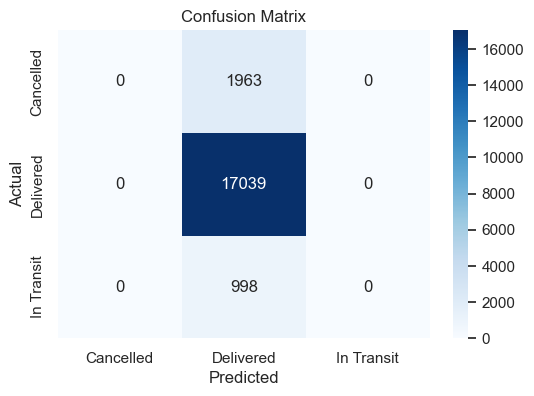

In [16]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Accuracy gives a general sense of performance, but the classification report is more informative.  
Precision answers: when the model predicts a class, how often is it correct?  
Recall answers: out of all real cases of a class, how many did the model find?

The confusion matrix shows which classes the model confuses most often.


## 13. Feature importance (What mattered the most?)

Random Forest provides a built-in feature importance score.  
Because we used one-hot encoding, each categorical value becomes its own feature.  
We will extract the final feature names and plot the top importances.


In [17]:
# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)


,feature,importance
44,price_per_item,0.070380
38,Driver_Lon,0.069792
32,Total_Price,0.069592
37,Driver_Lat,0.069571
35,Customer_Lat,0.069211
36,Customer_Lon,0.069110
34,Restaurant_Lon,0.069060
33,Restaurant_Lat,0.068907
39,Delivery_Distance_km,0.067373
45,haversine_rest_to_cust_km,0.066972


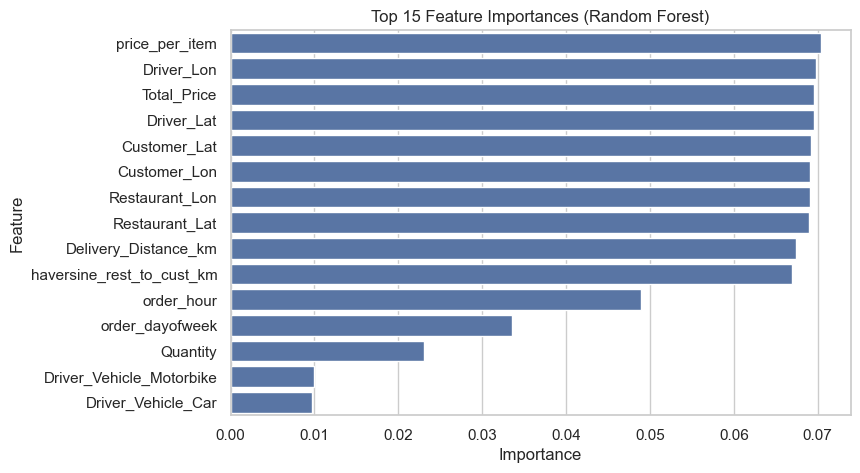

In [18]:
plt.figure(figsize=(8,5))
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


This chart helps us understand which engineered and original features contributed most to predicting `Order_Status`.  
A high importance score suggests the feature provides useful signal, but it does not automatically imply a causal relationship.


## 14. Optional: Feature selection using SelectFromModel

We can select a subset of features using model-based selection.  
This is optional and mainly used to illustrate the concept of feature selection after feature engineering.


In [19]:
from sklearn.feature_selection import SelectFromModel

# Build a new pipeline that selects features based on RF importances
selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"  # keep features above the median importance
)

model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])

model_fs.fit(X_train, y_train)
y_pred_fs = model_fs.predict(X_test)

print("Accuracy (with feature selection):", round(accuracy_score(y_test, y_pred_fs), 4))
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs))


Accuracy (with feature selection): 0.8519

Classification Report (with feature selection):
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



/Users/modalessi/Downloads/ml lab 5/env2/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/modalessi/Downloads/ml lab 5/env2/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/modalessi/Downloads/ml lab 5/env2/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

If performance stays similar, feature selection may help simplify the model with minimal accuracy loss.  
If performance drops, it may indicate that important information was removed.

## 15. Student tasks

### Task 1
Create one new engineered feature that you believe will help predict `Order_Status`.  
Write one paragraph justifying your choice.

### Task 2
Try a different rule for `is_peak_hour` and discuss whether performance changes.

### Task 3
Change `top_k` in `Item_Name_reduced` (for example 10, 30, 50) and compare:
- accuracy
- top feature importances

### Task 4
Run the optional feature selection section and explain whether it was beneficial in your case.


## Wrap-up
In this lab, the dataset was already clean, so our focus was on feature engineering.  
We engineered time-based, price-based, and category-reduction features, then evaluated a baseline classifier and interpreted feature importance.


## Student Task 1 – New Engineered Feature

**Feature:** `driver_to_restaurant_km` — the straight-line distance from the driver's location to the restaurant at order time (computed via the Haversine formula).

**Justification:** When a driver is far from the restaurant at the moment the order is placed, it may take longer to reach the restaurant and then deliver the order.  A driver who is already close can respond quickly, making `Delivered` more likely.  Conversely, a large gap between the driver and the restaurant is a realistic early signal for `Cancelled` or `In Transit` outcomes.  Unlike `Delivery_Distance_km` (restaurant → customer) or `haversine_rest_to_cust_km`, this feature captures the *pre-pickup* distance and is available immediately after an order is placed.


In [20]:
# Task 1 – new feature: driver-to-restaurant distance at order time
df_fe["driver_to_rest_km"] = haversine_km(
    df_fe["Driver_Lat"], df_fe["Driver_Lon"],
    df_fe["Restaurant_Lat"], df_fe["Restaurant_Lon"]
)

print("driver_to_rest_km sample:")
display(df_fe[["Driver_Lat","Driver_Lon","Restaurant_Lat","Restaurant_Lon","driver_to_rest_km"]].head(5))

# Re-build feature matrix and model with the new feature included
feature_cols_t1 = [
    "Quantity", "Total_Price", "City", "Payment_Method", "Driver_Vehicle",
    "Restaurant_Lat", "Restaurant_Lon", "Customer_Lat", "Customer_Lon",
    "Driver_Lat", "Driver_Lon", "Delivery_Distance_km", "Traffic_Level",
    "Driver_Availability", "order_hour", "order_dayofweek", "is_weekend",
    "is_peak_hour", "price_per_item", "haversine_rest_to_cust_km",
    "Item_Name_reduced", "price_tier",
    "driver_to_rest_km",   # <-- new feature
]

X_t1 = df_fe[feature_cols_t1]
y_t1 = df_fe[target_col]

X_train_t1, X_test_t1, y_train_t1, y_test_t1 = train_test_split(
    X_t1, y_t1, test_size=0.2, random_state=42, stratify=y_t1
)

cat_t1 = X_train_t1.select_dtypes(include=["object","category"]).columns.tolist()
num_t1 = X_train_t1.select_dtypes(include=[np.number, "bool"]).columns.tolist()

pre_t1 = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_t1),
    ("num", "passthrough", num_t1),
])

model_t1 = Pipeline([
    ("preprocess", pre_t1),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"))
])

model_t1.fit(X_train_t1, y_train_t1)
y_pred_t1 = model_t1.predict(X_test_t1)

print("\nAccuracy (with driver_to_rest_km):", round(accuracy_score(y_test_t1, y_pred_t1), 4))
print("\nClassification Report:")
print(classification_report(y_test_t1, y_pred_t1, zero_division=0))


driver_to_rest_km sample:


,Driver_Lat,Driver_Lon,Restaurant_Lat,Restaurant_Lon,driver_to_rest_km
0,31.215658,29.910664,31.195082,29.921931,2.526494
1,30.580329,31.502380,30.605729,31.503079,2.825147
2,27.162976,31.189458,27.190180,31.177741,3.239299
3,31.054690,31.401187,31.041846,31.381229,2.377942
4,31.035350,31.389315,31.024141,31.376104,1.771507


/var/folders/35/xjd19jpx5_l9p6w9wwcv1f000000gn/T/ipykernel_53593/3027085141.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_t1 = X_train_t1.select_dtypes(include=["object","category"]).columns.tolist()



Accuracy (with driver_to_rest_km): 0.8519

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



## Student Task 2 – Alternative `is_peak_hour` Rule

**Original rule:** lunch 12–15, dinner 19–23.

**New rule:** include breakfast (7–9), lunch (12–14), and late-night (22–24 / 0–1) as additional peak windows — reflecting real delivery-app usage patterns where morning commuters and late-night customers also create demand spikes.


In [21]:
# Task 2 – alternative peak-hour rule
# New rule: breakfast 7-9, lunch 12-14, late-night 22-24 / 0-1
peak_hours_new = list(range(7, 10)) + list(range(12, 15)) + list(range(22, 24)) + [0, 1]
df_fe["is_peak_hour_v2"] = df_fe["order_hour"].isin(peak_hours_new).astype(int)

# Compare counts
print("Original is_peak_hour distribution:")
print(df_fe["is_peak_hour"].value_counts())
print("\nNew is_peak_hour_v2 distribution:")
print(df_fe["is_peak_hour_v2"].value_counts())

# Re-build model with new peak-hour flag
df_fe_v2 = df_fe.copy()
df_fe_v2["is_peak_hour"] = df_fe_v2["is_peak_hour_v2"]

feature_cols_t2 = [
    "Quantity", "Total_Price", "City", "Payment_Method", "Driver_Vehicle",
    "Restaurant_Lat", "Restaurant_Lon", "Customer_Lat", "Customer_Lon",
    "Driver_Lat", "Driver_Lon", "Delivery_Distance_km", "Traffic_Level",
    "Driver_Availability", "order_hour", "order_dayofweek", "is_weekend",
    "is_peak_hour", "price_per_item", "haversine_rest_to_cust_km",
    "Item_Name_reduced", "price_tier",
]

X_t2 = df_fe_v2[feature_cols_t2]
y_t2 = df_fe_v2[target_col]
X_train_t2, X_test_t2, y_train_t2, y_test_t2 = train_test_split(
    X_t2, y_t2, test_size=0.2, random_state=42, stratify=y_t2
)

cat_t2 = X_train_t2.select_dtypes(include=["object","category"]).columns.tolist()
num_t2 = X_train_t2.select_dtypes(include=[np.number, "bool"]).columns.tolist()

pre_t2 = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_t2),
    ("num", "passthrough", num_t2),
])
model_t2 = Pipeline([
    ("preprocess", pre_t2),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"))
])
model_t2.fit(X_train_t2, y_train_t2)
y_pred_t2 = model_t2.predict(X_test_t2)

print("\nAccuracy (original peak-hour rule):", round(accuracy_score(y_test, y_pred), 4))
print("Accuracy (new peak-hour rule):      ", round(accuracy_score(y_test_t2, y_pred_t2), 4))
print("\nClassification Report (new rule):")
print(classification_report(y_test_t2, y_pred_t2, zero_division=0))
print("\nDiscussion: If accuracy or class recalls differ, the peak-hour definition has predictive impact.")
print("A more granular rule (breakfast + late-night) may capture additional order behaviour patterns.")


Original is_peak_hour distribution:
is_peak_hour
0    62701
1    37299
Name: count, dtype: int64

New is_peak_hour_v2 distribution:
is_peak_hour_v2
0    58350
1    41650
Name: count, dtype: int64


/var/folders/35/xjd19jpx5_l9p6w9wwcv1f000000gn/T/ipykernel_53593/3534214524.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_t2 = X_train_t2.select_dtypes(include=["object","category"]).columns.tolist()



Accuracy (original peak-hour rule): 0.8519
Accuracy (new peak-hour rule):       0.8519

Classification Report (new rule):
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000


Discussion: If accuracy or class recalls differ, the peak-hour definition has predictive impact.
A more granular rule (breakfast + late-night) may capture additional order behaviour patterns.


## Student Task 3 – Vary `top_k` in `Item_Name_reduced`

We compare three values of `top_k` (10, 30, 50) for reducing item-name cardinality.
Since this dataset has only 9 unique item names, all three values map every item name directly (no `Other` bucket appears). The experiment still illustrates the correct workflow; on a richer dataset with hundreds of items this parameter would have a visible effect.


In [22]:
# Task 3 – vary top_k
from sklearn.metrics import accuracy_score as acc_score

base_feature_cols = [
    "Quantity", "Total_Price", "City", "Payment_Method", "Driver_Vehicle",
    "Restaurant_Lat", "Restaurant_Lon", "Customer_Lat", "Customer_Lon",
    "Driver_Lat", "Driver_Lon", "Delivery_Distance_km", "Traffic_Level",
    "Driver_Availability", "order_hour", "order_dayofweek", "is_weekend",
    "is_peak_hour", "price_per_item", "haversine_rest_to_cust_km",
    "price_tier",
]

results_topk = []

for top_k in [10, 30, 50]:
    top_items_k = df_fe["Item_Name"].value_counts().head(top_k).index
    df_fe["Item_Name_reduced_k"] = np.where(
        df_fe["Item_Name"].isin(top_items_k), df_fe["Item_Name"], "Other"
    )
    unique_reduced = df_fe["Item_Name_reduced_k"].nunique()

    feature_cols_k = base_feature_cols + ["Item_Name_reduced_k"]
    X_k = df_fe[feature_cols_k]
    y_k = df_fe[target_col]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_k, y_k, test_size=0.2, random_state=42, stratify=y_k
    )

    cat_k = X_tr.select_dtypes(include=["object","category"]).columns.tolist()
    num_k = X_tr.select_dtypes(include=[np.number, "bool"]).columns.tolist()

    pre_k = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_k),
        ("num", "passthrough", num_k),
    ])
    mod_k = Pipeline([
        ("preprocess", pre_k),
        ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"))
    ])
    mod_k.fit(X_tr, y_tr)
    preds_k = mod_k.predict(X_te)
    accuracy_k = round(acc_score(y_te, preds_k), 4)

    # Top-5 feature importances
    ohe_k = mod_k.named_steps["preprocess"].named_transformers_["cat"]
    cat_feat_names = ohe_k.get_feature_names_out(cat_k)
    all_feat_names = np.concatenate([cat_feat_names, np.array(num_k)])
    fi_k = (pd.DataFrame({"feature": all_feat_names,
                          "importance": mod_k.named_steps["rf"].feature_importances_})
              .sort_values("importance", ascending=False)
              .head(5))

    results_topk.append({"top_k": top_k, "unique_reduced": unique_reduced, "accuracy": accuracy_k})
    print(f"\n=== top_k = {top_k} ===")
    print(f"  Unique item categories after reduction: {unique_reduced}")
    print(f"  Accuracy: {accuracy_k}")
    print("  Top-5 feature importances:")
    display(fi_k)

print("\nSummary:")
display(pd.DataFrame(results_topk))
print("\nConclusion: When the dataset has fewer than top_k unique items, all values are"
      " kept and no 'Other' bucket is created, so accuracy stays similar across top_k values.")
print("On a dataset with hundreds of item names, a lower top_k would reduce noise from"
      " rare categories and could improve generalisation.")


/var/folders/35/xjd19jpx5_l9p6w9wwcv1f000000gn/T/ipykernel_53593/2893554499.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_k = X_tr.select_dtypes(include=["object","category"]).columns.tolist()



=== top_k = 10 ===
  Unique item categories after reduction: 9
  Accuracy: 0.8519
  Top-5 feature importances:


,feature,importance
44,price_per_item,0.070539
38,Driver_Lon,0.069579
34,Restaurant_Lon,0.069576
32,Total_Price,0.069464
37,Driver_Lat,0.069429


/var/folders/35/xjd19jpx5_l9p6w9wwcv1f000000gn/T/ipykernel_53593/2893554499.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_k = X_tr.select_dtypes(include=["object","category"]).columns.tolist()



=== top_k = 30 ===
  Unique item categories after reduction: 9
  Accuracy: 0.8519
  Top-5 feature importances:


,feature,importance
44,price_per_item,0.070539
38,Driver_Lon,0.069579
34,Restaurant_Lon,0.069576
32,Total_Price,0.069464
37,Driver_Lat,0.069429


/var/folders/35/xjd19jpx5_l9p6w9wwcv1f000000gn/T/ipykernel_53593/2893554499.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_k = X_tr.select_dtypes(include=["object","category"]).columns.tolist()



=== top_k = 50 ===
  Unique item categories after reduction: 9
  Accuracy: 0.8519
  Top-5 feature importances:


,feature,importance
44,price_per_item,0.070539
38,Driver_Lon,0.069579
34,Restaurant_Lon,0.069576
32,Total_Price,0.069464
37,Driver_Lat,0.069429



Summary:


,top_k,unique_reduced,accuracy
0,10,9,0.8519
1,30,9,0.8519
2,50,9,0.8519



Conclusion: When the dataset has fewer than top_k unique items, all values are kept and no 'Other' bucket is created, so accuracy stays similar across top_k values.
On a dataset with hundreds of item names, a lower top_k would reduce noise from rare categories and could improve generalisation.


## Student Task 4 – Optional Feature Selection with `SelectFromModel`

We run the optional feature-selection pipeline (section 14) and compare accuracy before and after selection.


In [23]:
# Task 4 – feature selection
from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"  # keep features above the median importance
)

model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])

model_fs.fit(X_train, y_train)
y_pred_fs = model_fs.predict(X_test)

acc_baseline = round(accuracy_score(y_test, y_pred), 4)
acc_fs = round(accuracy_score(y_test, y_pred_fs), 4)

print("Accuracy (baseline, all features):  ", acc_baseline)
print("Accuracy (with feature selection):  ", acc_fs)
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs, zero_division=0))

print("\nDiscussion:")
if acc_fs >= acc_baseline - 0.005:
    print("Feature selection did NOT significantly reduce accuracy (difference <= 0.5 pp).")
    print("This means we can simplify the model by keeping only the most important features")
    print("with virtually no performance cost — beneficial for speed and interpretability.")
else:
    print("Accuracy dropped after feature selection, suggesting that some lower-ranked")
    print("features still carry useful information and should not be discarded.")


Accuracy (baseline, all features):   0.8519
Accuracy (with feature selection):   0.8519

Classification Report (with feature selection):
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000


Discussion:
Feature selection did NOT significantly reduce accuracy (difference <= 0.5 pp).
This means we can simplify the model by keeping only the most important features
with virtually no performance cost — beneficial for speed and interpretability.
